In [23]:
import math
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.optimize import brentq

def _aging_gompertz(x, aging_parameters):
    """
    Calculate mortality based on the Gompertz model.

    Arguments:
    x -- The age at which to calculate the mortality rate.
    aging_parameters -- A list containing the parameters for the Gompertz function:
        - aging_parameters[0] (a): The initial mortality rate (intercept).
        - aging_parameters[1] (b): The rate of increase in mortality rate with age (slope).

    Returns:
    Returns the mortality rate at age `x`, calculated using the provided `a` and `b` parameters.

    Examples:
    age = 50.0
    parameters = [0.01, 0.02]
    mortality_rate = _aging_gompertz(age, parameters)
    assert mortality_rate == 0.01 * math.exp(50.0 * 0.02)
    """
    a, b = aging_parameters[0], aging_parameters[1]
    return a * math.exp(x * b)

def constant_fertility(x):
    return 1.0

def step_fertility(x, start=15.0, end=100.0):
    if math.isinf(end):
        if x >= start:
            return 1.0
        else:
            return 0.0
    else:
        if x >= start and x <= end:
            return 1.0 
        else:
            return 0.0
    
def mortality_improvement_function(x, improvement_parameters):
    factor, start, end = improvement_parameters[0], improvement_parameters[1], improvement_parameters[2]
    
    if math.isinf(end):
        if x >= start:
            return factor
        else:
            return 1.0
    else:
        if x >= start and x <= end:
            return 1.0 - factor
        else:
            return 1.0

def toy_model(x, aging_func, improvement_func, aging_parameters, improvement_parameters, minimum_mortality):
    aging = aging_func(x, aging_parameters)
    improvement = improvement_func(x, improvement_parameters)

    result = aging * improvement

    if result < minimum_mortality:
        return minimum_mortality
    else:
        return result

def survival_l(x, aging_intermediate_func, aging_parameters, learning_parameters, growth_parameters):
    """
    Compute the survival function L(x) for a given x.

    Arguments:
    x -- The value at which to compute the survival function.
    aging_intermediate_func -- A function that computes the aging intermediate function.
    aging_parameters -- The aging parameters.
    learning_parameters -- The learning parameters.
    growth_parameters -- The growth parameters.

    Returns:
    The value of the survival function at x.
    """
    # Compute the cumulative hazard function at x. The integration method can be changed for better accuracy or faster computation.
    cumulative_hazard, _ = quad(
        lambda t: aging_intermediate_func(
            t,
            aging_parameters,
            learning_parameters,
            growth_parameters,
        ),
        0.0, x
    )
    return np.exp(-cumulative_hazard)

def cumulative_hazard(start, end, aging_intermediate_func, aging_parameters, learning_parameters, growth_parameters):
    """
    Compute the cumulative hazard function H(x) for a given x.

    Arguments:
    x -- The value at which to compute the cumulative hazard function.
    aging_intermediate_func -- A function that computes the aging intermediate function.
    aging_parameters -- The aging parameters.
    learning_parameters -- The learning parameters.
    growth_parameters -- The growth parameters.

    Returns:
    The value of the cumulative hazard function at x.
    """
    # Compute the cumulative hazard function at x. The integration method can be changed for better accuracy or faster computation.
    cumulative_hazard, _ = quad(
        lambda t: aging_intermediate_func(
            t,
            aging_parameters,
            learning_parameters,
            growth_parameters,
        ),
        start, end
    )
    return cumulative_hazard

def euler_lotka_function(r, aging_intermediate_func, aging_parameters, learning_parameters, growth_parameters, fertility_func):
    """
    Compute the Euler-Lotka function for a given r.

    Arguments:
    r -- The value of r for which to compute the Euler-Lotka function.
    aging_intermediate_func -- A function that computes the aging intermediate function.
    aging_parameters -- The aging parameters.
    learning_parameters -- The learning parameters.
    growth_parameters -- The growth parameters.
    fertility_func -- A function that computes the fertility function.

    Returns:
    The value of the Euler-Lotka function at r.
    """
    # Compute the integral
    integral, _ = quad(
        lambda t: fertility_func(t) * survival_l(
            t,
            aging_intermediate_func,
            aging_parameters,
            learning_parameters,
            growth_parameters,
        ) * np.exp(-r * t),
        0.0, 100.0
    )
    return integral - 1.0

def compute_fitness(aging_intermediate_func, aging_parameters, learning_parameters, growth_parameters, fertility_func):
    """
    Compute the fitness of a given set of parameters using the Euler-Lotka equation.

    Arguments:
    aging_intermediate_func -- A function that computes the aging intermediate function.
    aging_parameters -- The aging parameters.
    learning_parameters -- The learning parameters.
    growth_parameters -- The growth parameters.
    fertility_func -- A function that computes the fertility function.

    Returns:
    The fitness of the given set of parameters.
    """
    # Define the Euler-Lotka function as a closure
    def euler_lotka_closure(r):
        return euler_lotka_function(r, aging_intermediate_func, aging_parameters, learning_parameters, growth_parameters, fertility_func)

    # Attempt to find the root using Brent's method
    try:
        root = brentq(euler_lotka_closure, 0.0, 1.0, xtol=1e-15, maxiter=100)
        return max(root, 0.0)
    except ValueError as e:
        print(f"Failed to find root: {e}")
        return 0.0

In [24]:
aging_parameters = [0.01, 0.1]
improvement_parameters = [0.0, 15.0, 30.0]
fertility_parameters = [1.0]
minimum_mortality = 1e-5

age = np.linspace(0, 100, 100)
mortality = [toy_model(x, _aging_gompertz, mortality_improvement_function, aging_parameters, improvement_parameters, minimum_mortality) for x in age]

def aging_intermediate_func(x, aging_parameters, learning_parameters, growth_parameters):
    return toy_model(x, _aging_gompertz, mortality_improvement_function, aging_parameters, learning_parameters, growth_parameters)

survival = [survival_l(x, aging_intermediate_func, aging_parameters, improvement_parameters, minimum_mortality) for x in age]

fitness = compute_fitness(aging_intermediate_func, aging_parameters, improvement_parameters, minimum_mortality, step_fertility)

print(fitness)

0.09359907300483183


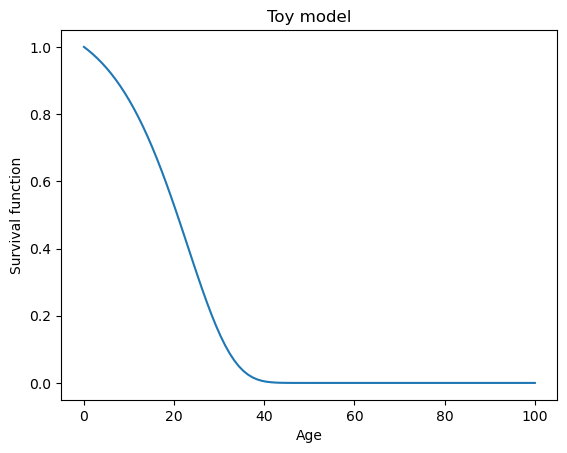

In [25]:
plt.plot(age, survival)
plt.xlabel('Age')
plt.ylabel('Survival function')
plt.title('Toy model')
plt.show()

In [26]:
aging_parameters = [0.02, 0.05]
improvement_parameters = [1.0, 15.0, 20.0]
fertility_parameters = [1.0]
minimum_mortality = 1e-5

age = np.linspace(0, 100, 100)
mortality = [toy_model(x, _aging_gompertz, mortality_improvement_function, aging_parameters, improvement_parameters, minimum_mortality) for x in age]

def aging_intermediate_func(x, aging_parameters, learning_parameters, growth_parameters):
    return toy_model(x, _aging_gompertz, mortality_improvement_function, aging_parameters, learning_parameters, growth_parameters)

survival = [survival_l(x, aging_intermediate_func, aging_parameters, improvement_parameters, minimum_mortality) for x in age]

fitness = compute_fitness(aging_intermediate_func, aging_parameters, improvement_parameters, minimum_mortality, step_fertility)

print(fitness)

/tmp/ipykernel_2191857/2634692458.py:84: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  cumulative_hazard, _ = quad(
/tmp/ipykernel_2191857/2634692458.py:137: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose

0.10288486506544418


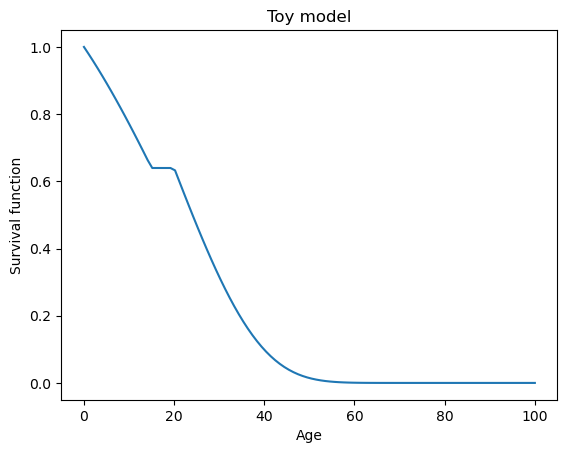

In [27]:
plt.plot(age, survival)
plt.xlabel('Age')
plt.ylabel('Survival function')
plt.title('Toy model')
plt.show()

In [30]:
aging_parameters = [0.01, 0.005226715]
improvement_parameters = [0.0, 0.0, 0.0]
fertility_parameters = [1.0]
minimum_mortality = 1e-5

age = np.linspace(0, 100, 100)

def a_control(x, aging_parameters, learning_parameters, growth_parameters):
    return toy_model(x, _aging_gompertz, mortality_improvement_function, aging_parameters, learning_parameters, growth_parameters)

print("Cumulative hazard from 0 to 100 (control) :", cumulative_hazard(0.0, 100.0, a_control, aging_parameters, improvement_parameters, minimum_mortality))
print("Cumulative hazard from 15 to 100 (control) :", cumulative_hazard(15.0, 100.0, a_control, aging_parameters, improvement_parameters, minimum_mortality))

aging_parameters = [0.01, 0.005633187]
improvement_parameters = [0.2, 0.0, np.inf]
fertility_parameters = [1.0]
minimum_mortality = 1e-5

def a_d_0(x, aging_parameters, learning_parameters, growth_parameters):
    return toy_model(x, _aging_gompertz, mortality_improvement_function, aging_parameters, learning_parameters, growth_parameters)

print("Cumulative hazard from 0 to 100 (d_0) :", cumulative_hazard(0.0, 100.0, a_d_0, aging_parameters, improvement_parameters, minimum_mortality))
print("Cumulative hazard from 15 to 100 (d_0) :", cumulative_hazard(15.0, 100.0, a_d_0, aging_parameters, improvement_parameters, minimum_mortality))

aging_parameters = [0.01, 0.005540846]
improvement_parameters = [0.2, 35.0, np.inf]
fertility_parameters = [1.0]
minimum_mortality = 1e-5

def a_d_35(x, aging_parameters, learning_parameters, growth_parameters):
    return toy_model(x, _aging_gompertz, mortality_improvement_function, aging_parameters, learning_parameters, growth_parameters)

print("Cumulative hazard from 0 to 100 (d_35) :", cumulative_hazard(0.0, 100.0, a_d_35, aging_parameters, improvement_parameters, minimum_mortality))
print("Cumulative hazard from 15 to 100 (d_35) :", cumulative_hazard(15.0, 100.0, a_d_35, aging_parameters, improvement_parameters, minimum_mortality))

Cumulative hazard from 0 to 100 (control) : 1.3134965157952823
Cumulative hazard from 15 to 100 (control) : 1.1574597348292321
Cumulative hazard from 0 to 100 (d_0) : 0.26858405678649383
Cumulative hazard from 15 to 100 (d_0) : 0.23728012325997244
Cumulative hazard from 0 to 100 (d_35) : 0.5762262457813264
Cumulative hazard from 15 to 100 (d_35) : 0.4198164518485687
